<a href="https://colab.research.google.com/github/Tasee-P/HW4/blob/main/HW4_Part1_PhachaT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


In [17]:
os.chdir('/content/drive/MyDrive')
!pwd

/content/drive/MyDrive


**Q1** Please use Pandas to read olympic_medals.csv and use parallel_categories function from plotly.express to visualize proportions of medal type for each gender from since year 2000. Please see the example in the Python notebook we walked through in the class.

In [18]:
#please use this cell to read and select your data
# Q1 need data from 2000
olym_df = pd.read_csv('/content/drive/MyDrive/olympic_medals.csv')
print(olym_df.head())

olym_df_filtered = olym_df[olym_df['Year'] >= 2000]



  Gender       Event Location  Year Medal                   Name Nationality  \
0      M  10000M Men      Rio  2016     G          Mohamed FARAH         GBR   
1      M  10000M Men      Rio  2016     S  Paul Kipngetich TANUI         KEN   
2      M  10000M Men      Rio  2016     B           Tamirat TOLA         ETH   
3      M  10000M Men  Beijing  2008     G        Kenenisa BEKELE         ETH   
4      M  10000M Men  Beijing  2008     S         Sileshi SIHINE         ETH   

     Result  
0  25:05.17  
1  27:05.64  
2  27:06.26  
3  27:01.17  
4  27:02.77  


In [19]:
#Code for Q1
fx = px.parallel_categories(
    olym_df_filtered,
    dimensions=['Gender','Medal'],
    color ='Year',
    color_continuous_scale = px.colors.sequential.Teal,

    title = 'Medal by gender (Since 2000)'
)
fx.show()




**Q2** Please inspect the code below and observe how values are plotted by running it. Then, read the 2016elections.csv from the DATA folder and select rows for AR, MI, CA, and WI. Then, utilize stacked bar plot, to stack vote percentages for Trump, Clinton, Johnson, and Others. Please see 'pct_clinton',	'pct_trump',	'pct_johnson',	'pct_other' columns. Make sure that your x tick labels are those four states above.

Text(0.5, 1.0, 'Monthly Temperatures in a year')

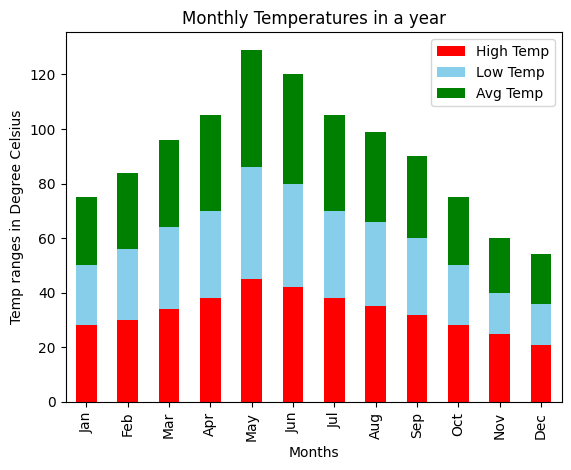

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# create DataFrame
df = pd.DataFrame({'High Temp': [28, 30, 34, 38, 45, 42,
                                 38, 35, 32, 28, 25, 21],
                   'Low Temp': [22, 26, 30, 32, 41, 38,
                                32, 31, 28, 22, 15, 15],
                   'Avg Temp': [25, 28, 32, 35, 43, 40,
                                35, 33, 30, 25, 20, 18]},
                  index=['Jan', 'Feb', 'Mar', 'Apr', 'May',
                         'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
                         'Nov', 'Dec'])


# create stacked bar chart for monthly temperatures
df.plot(kind='bar', stacked=True, color=['red', 'skyblue', 'green'])

# labels for x & y axis
plt.xlabel('Months')
plt.ylabel('Temp ranges in Degree Celsius')

# title of plot
plt.title('Monthly Temperatures in a year')

         state  fips  total_vote  vote_margin   winner       party  \
st                                                                   
AL     Alabama     1     2123372       588708    Trump  Republican   
AK      Alaska     2      318608        46933    Trump  Republican   
AZ     Arizona     4     2604657        91234    Trump  Republican   
AR    Arkansas     5     1130635       304378    Trump  Republican   
CA  California     6    14237893      4269978  Clinton  Democratic   

    pct_margin  r_points  d_points  pct_clinton  ...  pct_johnson  pct_other  \
st                                               ...                           
AL      0.2773     27.72    -27.72        34.36  ...         2.09       1.46   
AK      0.1473     14.73    -14.73        36.55  ...         5.88       6.29   
AZ      0.0350      3.50     -3.50        44.58  ...         4.08       3.25   
AR      0.2692     26.92    -26.92        33.65  ...         2.64       3.13   
CA      0.2999    -29.99     

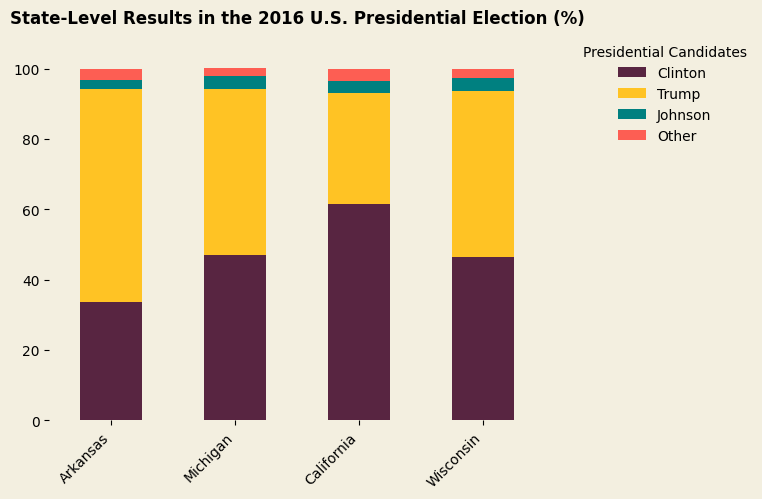

In [21]:

#Code for the Q2
elect_df = pd.read_csv('/content/drive/MyDrive/2016elections.csv').set_index('st')
print(elect_df.head())

#color are mangoteen, mango, dark teal, sunset
mycolors = ['#582541', '#FFC324', '#008080', '#FD5E53']

stacked_1 =  elect_df.loc[['AR','MI','CA','WI'], ['state','pct_clinton','pct_trump','pct_johnson','pct_other']]\
.set_index('state') \
.rename(columns={'pct_clinton': 'Clinton', 'pct_trump': 'Trump', 'pct_johnson': 'Johnson', 'pct_other':'Other'})\
.plot(kind='bar', stacked=True, color=mycolors)



stacked_1.set_facecolor('#F3EFE0')
plt.gcf().set_facecolor('#F3EFE0')

for spine in stacked_1.spines.values():
    spine.set_visible(False)
    #spine.set_color('red')
    #spine.set_linewidth(1.5)


plt.title('State-Level Results in the 2016 U.S. Presidential Election (%)', fontweight = 'bold', pad = 20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation = 45, ha= 'right')
plt.legend(title ="Presidential Candidates",bbox_to_anchor=(1.05, 1.05), loc='upper left', facecolor ='#F3EFE0', edgecolor = 'none')



plt.show ()
